In [1]:
import os
import math
import warnings
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.transforms.functional import resize as torch_resize
from torchvision.transforms.functional import InterpolationMode
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision.models import inception_v3
# Suppress deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# Device setup: use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [3]:
metadata_train_csv = 'processed_metadata_train.csv'
metadata_test_csv = 'processed_metadata_test.csv'
train_df = pd.read_csv(metadata_train_csv)
test_df = pd.read_csv(metadata_test_csv)

In [4]:
train_df.head(2)

,new_photo_id,label,original_photo_id,augmented
0,drink_1_1u4I3V3fhRDDfLHRbDwO9w,drink,1u4I3V3fhRDDfLHRbDwO9w,False
1,drink_2_kCob6wOKqwm6hXQ-WLYCOA,drink,kCob6wOKqwm6hXQ-WLYCOA,False


In [5]:
test_df.head(2)

,new_photo_id,label,original_photo_id,augmented
0,drink_1_8VfJq1vTpMh6IMKhtbsqHg,drink,8VfJq1vTpMh6IMKhtbsqHg,False
1,drink_2_3LGq6soWgPCWeVqaJCqCnw,drink,3LGq6soWgPCWeVqaJCqCnw,False


In [6]:
train_img_dir = 'original_photos_train'
test_img_dir = 'original_photos_test'

In [7]:
# === DDIM-Specific Configs  ===
# 1. Image Preprocessing
IMAGE_SIZE = 64  
CHANNELS = 3  # RGB
SCALE_RANGE = (-1, 1)  

# 2. Diffusion Hyperparameters
NUM_DIFFUSION_STEPS = 1000  # Training steps (DDIM can sample with fewer later)
BETA_SCHEDULE = "linear"  # Linear noise schedule 

# 3. Training Setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LR = 1e-4  # Standard for diffusion models

# 4. Reproducibility
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True  # 

# 5. Data Sampling 
SAMPLE_SIZE = 1000  # None for full dataset
LABELS = ['drink', 'food', 'inside', 'menu', 'outside'] 
NUM_GENERATE = 5  #no of image generated

# Brief check print
print(f"Train dataset entries: {len(train_df)}, Test dataset entries: {len(test_df)}")

Train dataset entries: 25000, Test dataset entries: 5000


 # DDIM-Optimized Dataset Class

In [8]:
class YelpDDIMDataset(Dataset):
    def __init__(self, meta_csv, img_dir, img_size=64, sample_n=None):
        df = pd.read_csv(meta_csv)
        assert 'original_photo_id' in df.columns, "Missing original_photo_id column"
        assert 'label' in df.columns, "Missing label column"

        if sample_n is not None:
            df = df.groupby('label').apply(
                lambda x: x.sample(min(len(x), sample_n), random_state=42)
            ).reset_index(drop=True)

        valid_indices = []
        for idx, row in df.iterrows():
            img_path = os.path.join(img_dir, f"{row['original_photo_id']}.jpg")
            if os.path.exists(img_path):
                valid_indices.append(idx)

        self.df = df.iloc[valid_indices].copy()
        self.img_dir = img_dir
        self.transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # scale to [-1,1] RGB
        ])
        self.label_map = {label: i for i, label in enumerate(LABELS)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['original_photo_id']}.jpg")
        img = Image.open(img_path).convert('RGB')
        label_idx = self.label_map[row['label']]
        return self.transform(img), label_idx


# Test Initialization

In [9]:
# Sample 1k/label for testing
train_data = YelpDDIMDataset(metadata_train_csv, train_img_dir, 
                            img_size=IMAGE_SIZE, sample_n=1000)
print(f"Train samples: {len(train_data)}")

Train samples: 5000


# DDIM U-Net Mode

In [10]:
def sinusoidal_embedding(timesteps, dim=128):
    half_dim = dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=128, label_emb_dim=128):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.act1 = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.SiLU(inplace=True)

        self.emb_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim + label_emb_dim, out_channels)
        )

    def forward(self, x, t_emb, label_emb):
        emb = torch.cat([t_emb, label_emb], dim=1)
        emb_out = self.emb_mlp(emb)[:, :, None, None]

        h = self.conv1(x)
        h = self.norm1(h)
        h = h + emb_out
        h = self.act1(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = h + emb_out
        h = self.act2(h)

        return h

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=128, label_emb_dim=128):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.double_conv = DoubleConv(in_channels, out_channels, time_emb_dim, label_emb_dim)

    def forward(self, x, t_emb, label_emb):
        x = self.pool(x)
        x = self.double_conv(x, t_emb, label_emb)
        return x

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=128, label_emb_dim=128):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, 2, stride=2)
        self.double_conv = DoubleConv(in_channels, out_channels, time_emb_dim, label_emb_dim)

    def forward(self, x1, x2, t_emb, label_emb):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        x = self.double_conv(x, t_emb, label_emb)
        return x

class DDIMUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=len(LABELS), time_emb_dim=128, label_emb_dim=128):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        self.inc = DoubleConv(in_channels, 64, time_emb_dim, label_emb_dim)
        self.down1 = DownBlock(64, 128, time_emb_dim, label_emb_dim)
        self.down2 = DownBlock(128, 256, time_emb_dim, label_emb_dim)
        self.down3 = DownBlock(256, 512, time_emb_dim, label_emb_dim)

        self.mid = DoubleConv(512, 512, time_emb_dim, label_emb_dim)

        self.up1 = UpBlock(512, 256, time_emb_dim, label_emb_dim)
        self.up2 = UpBlock(256, 128, time_emb_dim, label_emb_dim)
        self.up3 = UpBlock(128, 64, time_emb_dim, label_emb_dim)

        self.outc = nn.Conv2d(64, in_channels, 1)

    def forward(self, x, timesteps, labels):
        t_emb = sinusoidal_embedding(timesteps, dim=128)
        t_emb = self.time_mlp(t_emb)
        label_emb = self.label_emb(labels)
        x1 = self.inc(x, t_emb, label_emb)
        x2 = self.down1(x1, t_emb, label_emb)
        x3 = self.down2(x2, t_emb, label_emb)
        x4 = self.down3(x3, t_emb, label_emb)
        x_mid = self.mid(x4, t_emb, label_emb)
        x = self.up1(x_mid, x3, t_emb, label_emb)
        x = self.up2(x, x2, t_emb, label_emb)
        x = self.up3(x, x1, t_emb, label_emb)
        out = self.outc(x)
        return out

#  DDIM Noise Scheduler

In [11]:
class DDIMScheduler:
    def __init__(self, num_train_timesteps=NUM_DIFFUSION_STEPS, beta_schedule=BETA_SCHEDULE, device=DEVICE):
        if beta_schedule == "linear":
            self.betas = torch.linspace(1e-4, 0.02, num_train_timesteps, device=device)
        else:
            raise ValueError(f"Unsupported schedule: {beta_schedule}")

        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.], device=device), self.alphas_cumprod[:-1]])
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        self.device = device

    def add_noise(self, x_clean, timesteps, noise=None):
        if noise is None:
            noise = torch.randn_like(x_clean)
        timesteps = timesteps.view(-1, 1, 1, 1)
        sqrt_alpha = self.sqrt_alphas_cumprod[timesteps]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[timesteps]
        return sqrt_alpha * x_clean + sqrt_one_minus * noise

    @torch.no_grad()
    def sample(self, model, noise, num_steps=50, eta=0.0, labels=None):
        img = noise.clone()
        batch_size = noise.shape[0]
        step_indices = torch.linspace(0, NUM_DIFFUSION_STEPS - 1, num_steps + 1, dtype=torch.long, device=self.device)
        steps = step_indices.flip(0)

        for i in range(len(steps) - 1):
            t = steps[i]
            t_prev = steps[i + 1]
            t_batch = torch.full((batch_size,), t, device=self.device, dtype=torch.long)

            if labels is None:
                pred_noise = model(img, t_batch)
            else:
                pred_noise = model(img, t_batch, labels)

            alpha_t = self.alphas_cumprod[t]
            alpha_prev = self.alphas_cumprod_prev[t_prev]

            sigma_t = eta * ((1 - alpha_prev) / (1 - alpha_t)).sqrt() * (1 - alpha_t / alpha_prev).sqrt()

            x0_pred = (img - (1 - alpha_t).sqrt() * pred_noise) / alpha_t.sqrt()
            img = alpha_prev.sqrt() * x0_pred + (1 - alpha_prev - sigma_t ** 2).sqrt() * pred_noise

            if eta > 0:
                img += sigma_t * torch.randn_like(img)

        return img

# Test Noise Addition

In [12]:
# Initialize scheduler WITH DEVICE (critical)
scheduler = DDIMScheduler(device=DEVICE)  # <<< Now includes device parameter

# Simulate batch (using your dataset)
test_batch, _ = next(iter(DataLoader(train_data, batch_size=4)))
test_batch = test_batch.to(DEVICE)

# Generate random timesteps ON THE SAME DEVICE
timesteps = torch.randint(0, NUM_DIFFUSION_STEPS, (test_batch.shape[0],), device=DEVICE)

# Add noise - will now work perfectly
test_noisy_batch = scheduler.add_noise(test_batch, timesteps)

# Verification
print("\n=== DDIM Noise Test ===")
print(f"Clean batch device: {test_batch.device} | shape: {test_batch.shape}")
print(f"Timesteps device: {timesteps.device} | values: {timesteps.cpu().numpy()}")
print(f"Noisy batch device: {test_noisy_batch.device} | shape: {test_noisy_batch.shape}")
print(f"Max/min noise: {test_noisy_batch.max():.3f}/{test_noisy_batch.min():.3f}\n")


=== DDIM Noise Test ===
Clean batch device: cuda:0 | shape: torch.Size([4, 3, 64, 64])
Timesteps device: cuda:0 | values: [643 409 798 250]
Noisy batch device: cuda:0 | shape: torch.Size([4, 3, 64, 64])
Max/min noise: 3.922/-4.094



# DDIM Training Loop 

In [13]:
def train_ddim(
    model,
    scheduler,
    train_data,
    epochs=80,
    batch_size=128,
    lr=1e-4,
    device=DEVICE
):
    """DDIM training loop with label conditioning."""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        epoch_loss = 0
        for clean_images, labels in dataloader:
            clean_images = clean_images.to(device)
            labels = labels.to(device)

            timesteps = torch.randint(
                0, NUM_DIFFUSION_STEPS, (clean_images.shape[0],), device=device
            )
            noise = torch.randn_like(clean_images)
            noisy_images = scheduler.add_noise(clean_images, timesteps, noise)

            predicted_noise = model(noisy_images, timesteps, labels)

            loss = F.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)

        # ✅ Print loss every 10 epochs (and on epoch 1)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f}")


# Initialize model and scheduler once
model = DDIMUNet().to(DEVICE)
scheduler = DDIMScheduler(
    num_train_timesteps=NUM_DIFFUSION_STEPS,
    beta_schedule=BETA_SCHEDULE,
    device=DEVICE,
)

# Control training phases based on SAMPLE_SIZE
if SAMPLE_SIZE is not None:
    print(f"=== Training on sampled subset ({SAMPLE_SIZE} per label) for validation ===")
    sampled_train_data = YelpDDIMDataset(metadata_train_csv, train_img_dir, sample_n=SAMPLE_SIZE)
    train_ddim(model, scheduler, sampled_train_data, epochs=80, batch_size=128)

else:
    print("=== Training on full dataset ===")
    full_train_data = YelpDDIMDataset(metadata_train_csv, train_img_dir)
    train_ddim(model, scheduler, full_train_data, epochs=10, batch_size=124)

=== Training on sampled subset (1000 per label) for validation ===
Epoch 1/80 | Loss: 0.5318
Epoch 10/80 | Loss: 0.0526
Epoch 20/80 | Loss: 0.0485
Epoch 30/80 | Loss: 0.0449
Epoch 40/80 | Loss: 0.0389
Epoch 50/80 | Loss: 0.0370
Epoch 60/80 | Loss: 0.0372
Epoch 70/80 | Loss: 0.0383
Epoch 80/80 | Loss: 0.0370


# Image Generation

In [15]:
@torch.no_grad()
def generate_samples(
    model, 
    scheduler, 
    labels=LABELS,     # list of label names
    num_samples=NUM_GENERATE,  
    image_size=IMAGE_SIZE,
    device=DEVICE
):
    model.eval()
    samples = []

    # Generate one image per label, passing label indices for conditioning
    for label in labels:
        noise = torch.randn(1, CHANNELS, image_size, image_size, device=device)
        label_idx = torch.tensor([labels.index(label)], device=device)
        sample = scheduler.sample(model, noise, num_steps=50, eta=0.0, labels=label_idx)
        samples.append((label, sample))

    # Extra random label sample
    noise = torch.randn(1, CHANNELS, image_size, image_size, device=device)
    random_label_idx = torch.randint(0, len(labels), (1,), device=device)
    samples.append(("extra", scheduler.sample(model, noise, num_steps=200, eta=0.0, labels=random_label_idx)))

    return samples

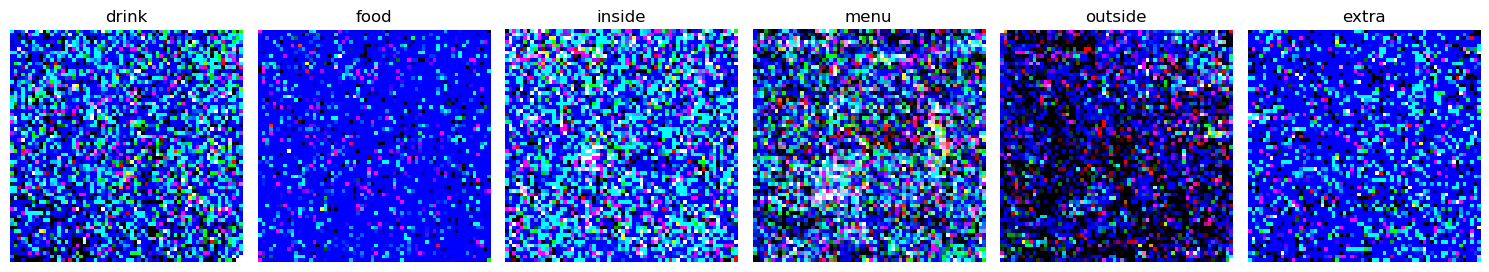

In [16]:
def display_samples(samples):

    plt.figure(figsize=(15, 3))
    for i, (label, img) in enumerate(samples):
        img = (img.squeeze().permute(1, 2, 0).cpu().numpy() + 1) / 2  # Normalize to [0,1]
        plt.subplot(1, len(samples), i+1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# ======== USAGE ======== #
final_samples = generate_samples(model, scheduler)
display_samples(final_samples)

In [17]:
def evaluate_fid_is(generated_samples, real_img_dir, test_df, device=torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    # Initialize metrics (feature=2048 uses Inception V3 final pooling layer)
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)
    is_metric = InceptionScore(normalize=True).to(device)

    preprocess_real = transforms.Compose([
        transforms.Resize((299, 299), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),  # float tensor in [0,1]
    ])

    # Sample 100 real images reproducibly
    sampled_img_ids = test_df['original_photo_id'].sample(100, random_state=42)
    real_images = []
    for photo_id in sampled_img_ids:
        try:
            path = f"{real_img_dir}/{photo_id}.jpg"
            img = Image.open(path).convert("RGB")
            img = preprocess_real(img).unsqueeze(0)  # [1,3,299,299]
            real_images.append(img)
        except Exception as e:
            print(f"Warning: failed to load image {photo_id}: {e}")
    real_images = torch.cat(real_images, dim=0).to(device)  # [N,3,299,299] float [0,1]

    # Convert real images to uint8 in [0,255] for FID/IS
    real_images_uint8 = (real_images * 255).to(torch.uint8)

    # Prepare generated images
    preprocess_fake = transforms.Compose([
        transforms.Resize((299,299), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),  # converts PIL image to float [0,1]
    ])

    fake_images = []
    for _, img in generated_samples:
        # img: [1,C,H,W] tensor, values in [-1,1]
        img_np = (img.squeeze(0).permute(1,2,0).cpu().numpy() + 1) / 2  # scale to [0,1]
        pil_img = Image.fromarray((img_np * 255).astype(np.uint8))
        tensor_img = preprocess_fake(pil_img)  # tensor [3,299,299], float [0,1]
        fake_images.append(tensor_img)

    fake_images = torch.stack(fake_images).to(device)  # [N,3,299,299], float
    fake_images_uint8 = (fake_images * 255).to(torch.uint8)

    batch_size = 32  # adjust according to your GPU

    # Update FID with real samples
    for i in range(0, real_images_uint8.size(0), batch_size):
        fid_metric.update(real_images_uint8[i:i+batch_size], real=True)

    # Update FID and IS with fake samples
    for i in range(0, fake_images_uint8.size(0), batch_size):
        batch = fake_images_uint8[i:i+batch_size]
        fid_metric.update(batch, real=False)
        is_metric.update(batch)

    # Compute final scores
    fid_score = fid_metric.compute().item()
    inception_score_val, inception_score_std = is_metric.compute()

    print(f"FID: {fid_score:.4f} | Inception Score: {inception_score_val:.4f} ± {inception_score_std:.4f}")

In [18]:
evaluate_fid_is(
    final_samples,   
    test_img_dir,    
    test_df          
)

c:\Users\kauth\OneDrive\Desktop\Loyalist College\CV\Image_generator_model\cv2_env\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID: 529.1235 | Inception Score: 1.0000 ± 0.0000


LLM: CHATGPT
`First Prompt:` BUild A DDIM model for me.
`last Prompt:` How can i make the model better
